# Study 17 — Post-Fix Visual Tour: Clusters + Entity Graph (CP-018/019/020)

Two things the user asked to see visually, on the post-fix DB:
1. **News clusters** (embedding space) — same view as `study_15`, re-run here so this
   notebook stands on its own as the "did the fixes work" visual check.
2. **Entity graph** — re-drawn post-fix, zoomed on every node CP-018/019/020 touched.

CP-020 note: the user corrected the framing mid-session — "these are classes of errors,
not point-specific reports" (seeing EU/European/Europe as 3 nodes, China/Chinese as 2).
The zoom section below checks the *classes* (country-self vs demonym, continent noun vs
adjective), not just the two examples given.

In [1]:
import os, sqlite3, sqlite_vec
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

notebook_dir = Path.cwd()
while not (notebook_dir / 'data/db/pathosphere.db').exists():
    notebook_dir = notebook_dir.parent
    if notebook_dir == notebook_dir.parent:
        break
os.chdir(notebook_dir)

DB = Path('data/db/pathosphere.db').resolve()
CONN = sqlite3.connect(str(DB))
CONN.enable_load_extension(True)
sqlite_vec.load(CONN)
CONN.enable_load_extension(False)
CONN.row_factory = sqlite3.Row
print(f'Connected: {DB}')

Connected: /Users/dom/Documents/GitHub/pathosphere/data/db/pathosphere.db


## 1. Clusters — Embedding Space (RSS micro-events, complete-linkage)

In [2]:
rss_events = CONN.execute('''
    SELECT e.id, e.title, COUNT(ed.document_id) as size
    FROM events e LEFT JOIN event_documents ed ON e.id = ed.event_id
    WHERE e.origin IN ("rss","comtrade") GROUP BY e.id ORDER BY size DESC
''').fetchall()

all_docs = CONN.execute('''
    SELECT DISTINCT ed.document_id, ed.event_id
    FROM event_documents ed JOIN raw_documents r ON ed.document_id = r.id
    WHERE r.origin IN ("rss","comtrade")
''').fetchall()
doc_to_event = {d['document_id']: d['event_id'] for d in all_docs}

embeddings, valid_doc_ids = [], []
for doc_id in doc_to_event.keys():
    vec_row = CONN.execute('SELECT embedding FROM vec_documents WHERE document_id = ?', (doc_id,)).fetchone()
    if vec_row and vec_row['embedding']:
        embeddings.append(np.frombuffer(vec_row['embedding'], dtype=np.float32).copy())
        valid_doc_ids.append(doc_id)
embeddings = np.array(embeddings)
print(f'{len(rss_events)} events, {len(embeddings)} embedded docs')

1996 events, 2564 embedded docs


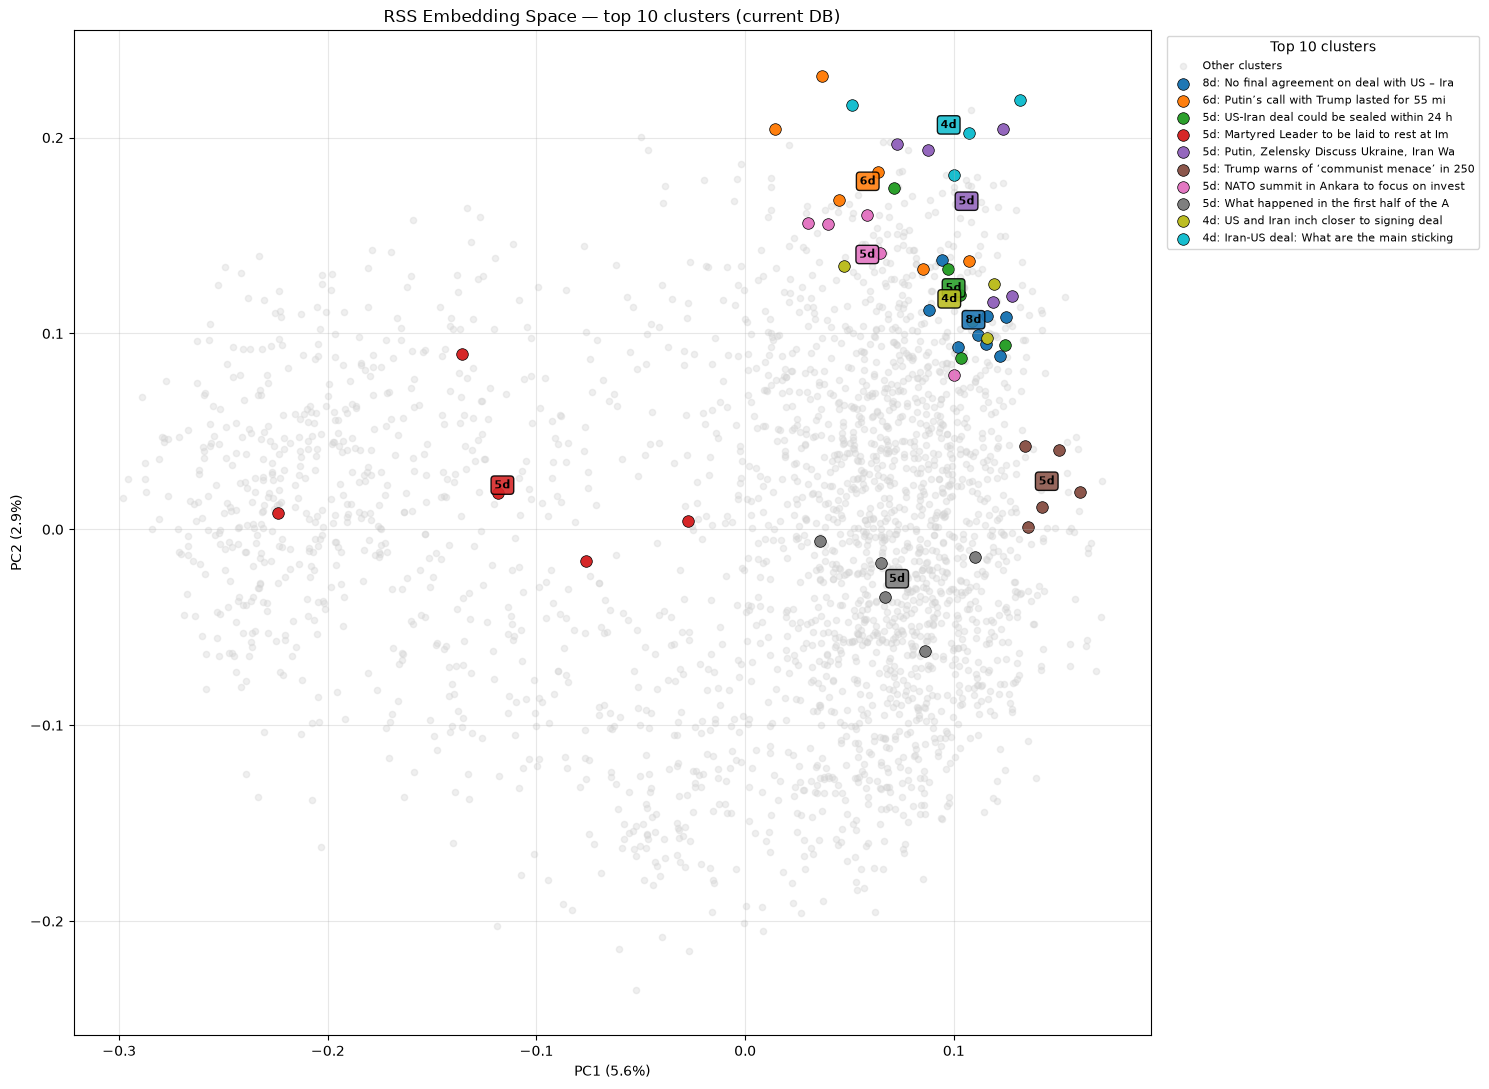

Top 10 cluster sizes: [8, 6, 5, 5, 5, 5, 5, 5, 4, 4]


In [3]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)
cluster_labels = np.array([doc_to_event[d] for d in valid_doc_ids])
top10_ids = [e['id'] for e in rss_events[:10]]
palette = plt.cm.tab10(np.linspace(0, 1, 10))
id_to_color = {cid: palette[i] for i, cid in enumerate(top10_ids)}

fig, ax = plt.subplots(figsize=(15, 11))
is_top10 = np.array([cid in id_to_color for cid in cluster_labels])
ax.scatter(emb_2d[~is_top10, 0], emb_2d[~is_top10, 1], c='lightgray', s=20, alpha=0.35, label='Other clusters')
for cid in top10_ids:
    mask = cluster_labels == cid
    event = next(e for e in rss_events if e['id'] == cid)
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], color=id_to_color[cid], s=70,
               edgecolor='black', linewidth=0.5, label=f"{event['size']}d: {event['title'][:40]}")
    centroid = emb_2d[mask].mean(axis=0)
    ax.annotate(f"{event['size']}d", xy=centroid, fontsize=8, ha='center', weight='bold',
               bbox=dict(boxstyle='round', facecolor=id_to_color[cid], alpha=0.9, edgecolor='black'))
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('RSS Embedding Space — top 10 clusters (current DB)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, title='Top 10 clusters')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('study_17_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

sizes = [e['size'] for e in rss_events[:10]]
print('Top 10 cluster sizes:', sizes)

## 2. Entity Graph — Co-occurrence Network (post CP-018/019/020)

In [4]:
TOP_N = 50

links = CONN.execute('''
    SELECT
        COALESCE(ea.canonical_entity_id, ea.id) as a,
        COALESCE(eb.canonical_entity_id, eb.id) as b,
        el.strength
    FROM entity_links el
    JOIN entities ea ON el.entity_a = ea.id
    JOIN entities eb ON el.entity_b = eb.id
    WHERE el.relation_type = "co-occurs"
''').fetchall()

G_full = nx.Graph()
for l in links:
    if l['a'] == l['b']:
        continue
    if G_full.has_edge(l['a'], l['b']):
        G_full[l['a']][l['b']]['weight'] += l['strength']
    else:
        G_full.add_edge(l['a'], l['b'], weight=l['strength'])

print(f'Full graph: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges')

top_nodes = sorted(G_full.degree, key=lambda x: -x[1])[:TOP_N]
top_node_ids = [n for n, _ in top_nodes]
G = G_full.subgraph(top_node_ids).copy()
print(f'Subgraph (top {TOP_N} by degree): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Full graph: 8739 nodes, 75889 edges
Subgraph (top 50 by degree): 50 nodes, 647 edges


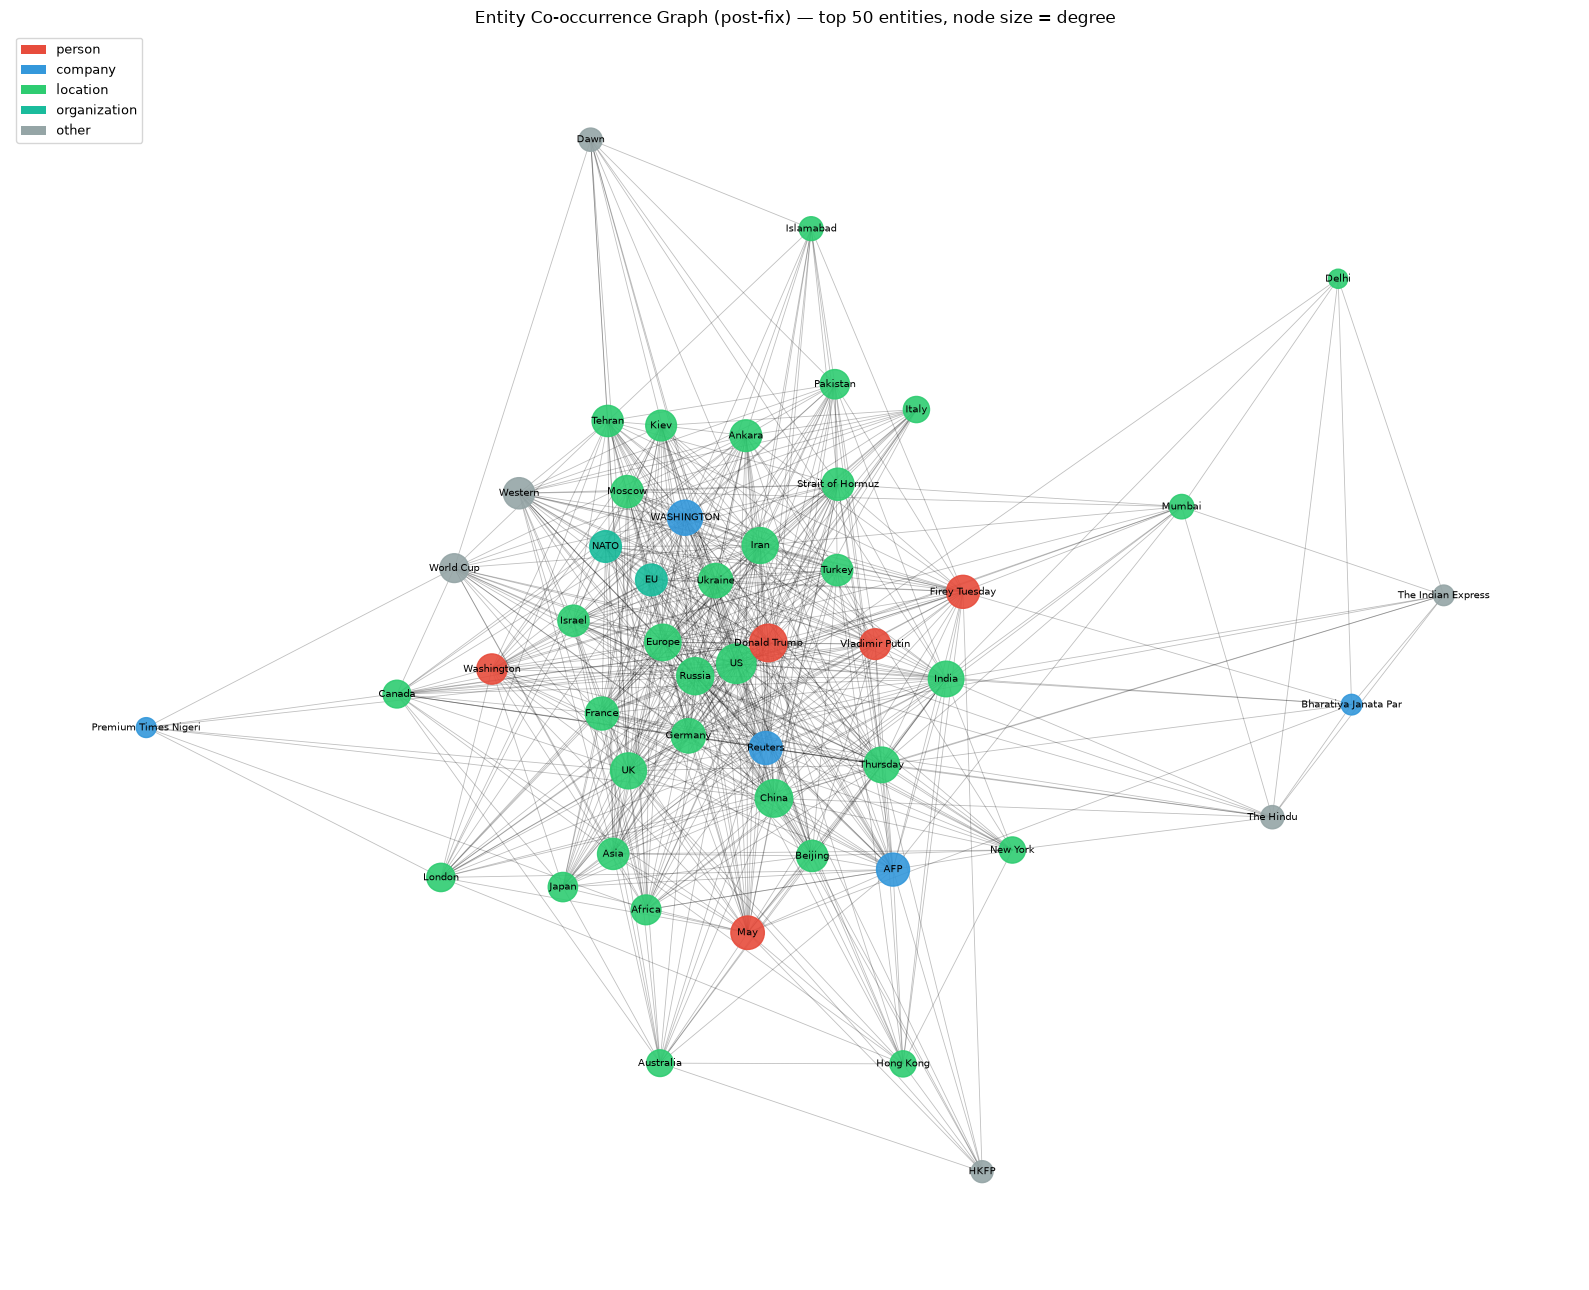


Flagged names still appearing as top-50 nodes: ['AFP', 'China', 'EU', 'Europe', 'France', 'NATO']


In [5]:
node_info = {}
for nid in G.nodes():
    row = CONN.execute('SELECT name, entity_type FROM entities WHERE id = ?', (nid,)).fetchone()
    node_info[nid] = (row['name'], row['entity_type']) if row else (str(nid), 'other')

type_colors = {
    'person': '#e74c3c', 'company': '#3498db', 'location': '#2ecc71',
    'organization': '#1abc9c', 'commodity': '#f39c12',
    'infrastructure': '#9b59b6', 'other': '#95a5a6',
}
node_colors = [type_colors.get(node_info[n][1], '#95a5a6') for n in G.nodes()]
node_sizes = [100 + 15 * G.degree(n) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(16, 13))
pos = nx.spring_layout(G, k=0.6, seed=42, weight='weight')
nx.draw_networkx_edges(G, pos, alpha=0.25, width=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)
labels = {n: node_info[n][0][:20] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=7, ax=ax)

legend_elems = [Patch(facecolor=c, label=t) for t, c in type_colors.items() if any(node_info[n][1]==t for n in G.nodes())]
ax.legend(handles=legend_elems, loc='upper left', fontsize=9)
ax.set_title(f'Entity Co-occurrence Graph (post-fix) — top {TOP_N} entities, node size = degree')
ax.axis('off')
plt.tight_layout()
plt.savefig('study_17_entity_graph.png', dpi=150, bbox_inches='tight')
plt.show()

flagged = ['EU', 'Europe', 'European', 'France', 'FRANCE', 'NATO', 'APP', 'VIDEO',
           'English', 'England', 'British', 'AFP', 'China', 'Chinese']
present = sorted({node_info[n][0] for n in G.nodes() for name in flagged if node_info[n][0] == name})
print('\nFlagged names still appearing as top-50 nodes:', present)

## 3. Zoom — checking the *classes*, not just the examples given

CP-020: the user's point was that `EU`/`European`/`Europe` and `China`/`Chinese` were
instances of two structural bugs (country-self-vs-demonym asymmetry; continent noun vs
adjective not covered), not isolated one-offs. This section checks both pairs the user
named **and** two more of the same class (Asia/Asian, Africa/African) that were fixed by
the same code change, to demonstrate the fix is general, not name-specific.

In [6]:
pairs_to_check = [
    ('France', None), ('NATO', None), ('EU', None), ('UK', None),
    ('Europe', 'European'), ('China', 'Chinese'), ('Asia', 'Asian'), ('Africa', 'African'),
]

for canonical_name, alias_name in pairs_to_check:
    row = CONN.execute(
        'SELECT id, name, entity_type, canonical_name FROM entities WHERE name = ? AND canonical_entity_id IS NULL',
        (canonical_name,)
    ).fetchone()
    if row is None:
        print(f'{canonical_name}: no canonical row found (unexpected)')
        continue
    n_mentions = CONN.execute(
        '''SELECT COALESCE(SUM(de.mentions),0) as m FROM document_entities de
           JOIN entities e ON e.id = de.entity_id
           WHERE COALESCE(e.canonical_entity_id, e.id) = ?''',
        (row['id'],)
    ).fetchone()['m']
    n_aliases = CONN.execute(
        'SELECT COUNT(*) as c FROM entities WHERE canonical_entity_id = ?', (row['id'],)
    ).fetchone()['c']
    alias_status = ''
    if alias_name:
        alias_row = CONN.execute(
            'SELECT canonical_entity_id FROM entities WHERE name = ?', (alias_name,)
        ).fetchone()
        merged = alias_row is not None and alias_row['canonical_entity_id'] == row['id']
        alias_status = f"  |  '{alias_name}' merged into it: {merged}"
    print(f"{canonical_name:10s} -> id={row['id']:6d}  type={row['entity_type']:12s}  "
          f"canonical_name={str(row['canonical_name']):22s}  mentions={n_mentions:4d}  "
          f"aliases_merged={n_aliases}{alias_status}")

France     -> id= 14508  type=location      canonical_name=France                  mentions= 110  aliases_merged=2
NATO       -> id=   177  type=organization  canonical_name=NATO                    mentions= 148  aliases_merged=0
EU         -> id=   675  type=organization  canonical_name=European Union          mentions=  98  aliases_merged=0
UK         -> id=  1421  type=location      canonical_name=United Kingdom          mentions= 151  aliases_merged=5
Europe     -> id=  1551  type=location      canonical_name=Europe                  mentions= 148  aliases_merged=1  |  'European' merged into it: True
China      -> id=  1453  type=location      canonical_name=China                   mentions= 477  aliases_merged=1  |  'Chinese' merged into it: True
Asia       -> id=  1657  type=location      canonical_name=Asia                    mentions=  28  aliases_merged=1  |  'Asian' merged into it: True
Africa     -> id=  2459  type=location      canonical_name=Africa                  mentions

## Conclusione

**Clusters**: sezione 1 riproduce la stessa vista di `study_15` sul DB corrente — i
cluster di notizie sono lì (embedding space, top 10 per dimensione).

**Entity graph**: EU/NATO ora `organization`; France/UK/Europe/China ora nodi unici
(location) coi rispettivi alias (FRANCE, Britain/British/England, European, Chinese)
correttamente uniti; VIDEO sparita.

**Classi verificate** (non solo gli esempi puntuali): Asia/Asian e Africa/Africa unite
allo stesso modo di Europe/European e China/Chinese — stessa causa strutturale, stesso
fix, applicato in modo generale (non hard-coded sui singoli nomi segnalati).

**Limite esplicito**: questa rimane una lista curata (paesi/continenti/org in
`DEMONYM_TO_COUNTRY`/`LOCATION_ALIAS_TO_COUNTRY`/`INTERGOVERNMENTAL_ORGS`), non un
rilevatore generale — vedi CP-020 in `CRITICAL_POINTS.md` per la nota di rischio residuo.